In [ ]:
import tools.ai_gpt_ep as gpt
visualizer = gpt.TrainingVisualizer('model/my_wiky_history.json')
visualizer.plot_metrics(window_size=10, lim_y=(2.5,10.2)) # Lissage sur 10 fichiers

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os, json, datetime

# --- Paramètres
seconds_per_10_steps = 95.0 
history_path = 'model/my_wiky_history.json'
window_size = 50
target = 2.7  
max_projection_steps = 100000 # On force l'affichage jusqu'ici

def loss_predict_func(x, a, b, c):
    return a * np.exp(-b * np.log(x + 1)) + c

def load_data():
    if not os.path.exists(history_path):
        return None
    try:
        with open(history_path, 'r') as f:
            return json.load(f)
    except (json.JSONDecodeError, Exception):
        return None

# --- Chargement et Préparation
data = load_data() # Ta fonction load_data()
val_loss = np.array(data.get('val_loss', []))
val_smooth = np.convolve(val_loss, np.ones(window_size)/window_size, mode='valid')
steps = np.array(data.get('steps', []))[window_size-1:]
current_step = steps[-1]

# --- Calcul de la Prédiction
x_data_k = steps / 1000.0
y_data = val_smooth
initial_guess = [1.0, 0.5, 2.0]
bounds = ([0, 0, 0], [np.inf, 5, 4])

try:
    popt, _ = curve_fit(loss_predict_func, x_data_k, y_data, p0=initial_guess, bounds=bounds)
    
    # On crée la projection jusqu'à max_projection_steps
    future_steps = np.linspace(0, max_projection_steps, 2000)
    future_steps_k = future_steps / 1000.0
    predicted_vals = loss_predict_func(future_steps_k, *popt)
    
    # Seuil minimal théorique (le paramètre 'c' de la fonction)
    min_possible_loss = popt[2]
    
    # Trouver le step cible
    idx_target = np.where(predicted_vals <= target)[0]
    step_target = future_steps[idx_target[0]] if len(idx_target) > 0 else None
except Exception as e:
    print(f"⚠️ Erreur : {e}")
    step_target = None

# --- Graphique
plt.figure(figsize=(12, 7))

# 1. Données réelles
plt.plot(steps, val_smooth, label='Données réelles (smooth)', color='orange', linewidth=2)

# 2. Projection (on affiche tout le futur)
plt.plot(future_steps[future_steps >= current_step], 
         predicted_vals[future_steps >= current_step], 
         '--', label='Projection théorique', color='gray', alpha=0.6)

# --- GESTION DE L'AFFICHAGE ET DES LIMITES ---
plt.xlim(0, max_projection_steps) # FORCER L'AXE X JUSQU'À 100k
plt.ylim(min(val_smooth)*0.9, max(val_smooth)*1.1) # Ajuster l'axe Y pour voir la descente

if step_target:
    # Calcul temporel
    steps_to_go = step_target - current_step
    total_seconds = (steps_to_go / 10) * seconds_per_10_steps
    finish_date = datetime.datetime.now() + datetime.timedelta(seconds=total_seconds)
    
    plt.axvline(x=step_target, color='green', linestyle=':', label=f'Cible @ {int(step_target)} steps')
    plt.scatter([step_target], [target], color='green')
    plt.annotate(f"Objectif atteint le :\n{finish_date.strftime('%d/%m %H:%M')}", 
                 xy=(step_target, target), xytext=(step_target*0.5, target-0.2),
                 arrowprops=dict(arrowstyle="->", color='black'))
else:
    print(f"ℹ️ La cible {target} semble inatteignable avec la pente actuelle.")
    print(f"📉 Minimum théorique prédit : {min_possible_loss:.3f}")

plt.title(f"Convergence du Modèle : État à {int(current_step)} steps")
plt.xlabel("Nombre de Steps")
plt.ylabel("Loss")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os, json, datetime

# --- Paramètres
seconds_per_10_steps = 95.0  # La moyenne observée sur les derniers logs
history_path = 'model/my_wiky_history.json'
window_size = 10
target = 2.7

# --- 1. FONCTION DE TENDANCE (Power Law) ---
# En deep learning, la loss suit souvent une loi de puissance : y = a * x^-b + c
def loss_predict_func(x, a, b, c):
    return a * np.exp(-b * np.log(x + 1)) + c
    # return a * np.power(x + 1, -b) + c

def load_data():
    if not os.path.exists(history_path):
        return None
    try:
        with open(history_path, 'r') as f:
            return json.load(f)
    except (json.JSONDecodeError, Exception):
        return None

# --- 2. EXTRACTION ET PRÉPARATION (Simulation des données de ton log) ---
# Remplace ces listes par l'extraction de tes fichiers logs
data = load_data()
steps = np.array(data.get('steps', []))[window_size-1:]
val_loss = np.array(data.get('val_loss', []))
val_smooth = np.convolve(val_loss, np.ones(window_size)/window_size, mode='valid')
current_step = steps[-1]     # Le dernier step atteint

print(len(val_smooth), len(val_loss),len(steps))

# val_loss = np.array(ta_val_loss_smooth)

# --- 3. CALCUL DE LA PRÉDICTION ---
# On "fit" (ajuste) la courbe sur les données réelles (après le warmup)
# popt contient les coefficients optimaux [a, b, c]
x_data = steps / 1000.0 
y_data = val_smooth

# 3. Estimation initiale (Guess)
# a: échelle, b: taux de décroissance, c: limite vers laquelle tend la loss (ex: 2.0)
initial_guess = [1.0, 0.5, 2.0]
# On définit des limites : b doit être positif, c ne peut pas être négatif
bounds = ([0, 0, 0], [np.inf, 5, 4])

try:
    # popt, _ = curve_fit(loss_predict_func, steps[500:], val_smooth[500:], maxfev=10000)
    popt, _ = curve_fit(loss_predict_func, x_data, y_data, p0=initial_guess, bounds=bounds)

    # Projection sur 100k steps (en kilo-steps)
    future_x = np.arange(0, 100, 1) 
    predicted_vals = loss_predict_func(future_x, *popt)
    
    # Conversion inverse pour le résultat final
    step_target_k = future_x[np.where(predicted_vals <= target)[0][0]]
    print(f"🎯 Cible 2.5 estimée aux alentours du step : {int(step_target_k * 1000)}")
    

except Exception as e:
    print(f"⚠️ Erreur de fit : {e}. Continue l'entraînement, les données sont encore trop instables.")
    step_target_k = None

# --- 4. LE GRAPHIQUE ---
plt.figure(figsize=(12, 6))
plt.plot(steps, val_smooth, label='Val Loss réelle (smooth)', color='orange')
plt.plot(future_x, predicted_vals, '--', label='Tendance prédictive', color='gray', alpha=0.7)

print(step_target_k)

if step_target_k:
    # 1. Calcul de la distance en steps
    steps_to_go = step_target_k - current_step
    
    if steps_to_go > 0:
        # 2. Conversion en secondes, puis heures
        total_seconds_needed = (steps_to_go / 10) * seconds_per_10_steps
        hours_needed = total_seconds_needed / 3600
        
        # 3. Calcul de la date et l'heure de fin estimée
        finish_date = datetime.datetime.now() + datetime.timedelta(seconds=total_seconds_needed)
        
        print(f"\n--- ⏳ ESTIMATION TEMPORELLE ---")
        print(f"Steps restants : {int(steps_to_go)}")
        print(f"Temps requis   : {hours_needed:.1f} heures (soit {hours_needed/24:.1f} jours)")
        print(f"Arrivée à 2.5  : {finish_date.strftime('%A %d %B à %H:%M')}")
        print(f"--------------------------------\n")
    else:
        print("🎉 Selon la tendance, tu devrais déjà être sous 2.5 (ou très proche) !")

    plt.axvline(x=step_target_k, color='green', linestyle=':', alpha=0.5)
    plt.scatter([step_target_k], [target], color='green', zorder=5)
    plt.annotate(f'Cible 2.5 @ Step {int(step_target_k)}', 
                 xy=(step_target_k, target), xytext=(step_target_k+2, target+0.2),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.title("Évolution et Prédiction du Loss (Wiki FR)")
plt.xlabel("Nombre de steps")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [ ]:
import torch

# Vide le cache des allocations Metal (MPS)
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
    print("🧹 Cache MPS vidé.")

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 1. Chargement
log_path = 'model/my_wiky_history.json'
with open(log_path, 'r') as f:
    data = json.load(f)

# Extraction des listes (Structure détectée : dict de listes)
steps = data['steps']
train_loss = data['train_loss']
val_loss = data['val_loss']

# Calcul du Gap
gap = np.array(val_loss) - np.array(train_loss)

# 2. Création du graphique
plt.figure(figsize=(14, 7))

# Courbes principales
plt.plot(steps, train_loss, label='Train Loss', color='#3498db', lw=1.5, alpha=0.8)
plt.plot(steps, val_loss, label='Val Loss', color='#e67e22', lw=2)

# Coloration dynamique du Gap (Zone verte/jaune/rouge)
# On remplit l'espace entre Train et Val pour voir l'évolution de la généralisation
plt.fill_between(steps, train_loss, val_loss, 
                 where=(gap <= 0.05), color='green', alpha=0.2, label='Gap Optimal (<0.05)')

plt.fill_between(steps, train_loss, val_loss, 
                 where=(gap > 0.05) & (gap <= 0.12), color='yellow', alpha=0.3, label='Gap Alerte (<0.12)')

plt.fill_between(steps, train_loss, val_loss, 
                 where=(gap > 0.12), color='red', alpha=0.3, label='Overfitting (>0.12)')

# Focus sur la fin de l'entraînement (ton passage à 0.15 de dropout)
last_step = steps[-1]
plt.axvline(x=19500, color='purple', linestyle='--', alpha=0.5, label='Passage Dropout 0.15')

# Style
plt.title(f"Poussin-V2 : Historique de Training (Step {last_step})", fontsize=15)
plt.xlabel("Nombre de Steps")
plt.ylabel("Loss")
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# 3. Stats de fin de run
print(f"📈 ANALYSE DERNIER POINT (Step {last_step})")
print(f"Train Loss : {train_loss[-1]:.4f}")
print(f"Val Loss   : {val_loss[-1]:.4f}")
print(f"Gap actuel : {gap[-1]:.4f}")

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 1. Chargement
log_path = 'model/my_wiky_history.json'
with open(log_path, 'r') as f:
    data = json.load(f)

steps = data['steps']
train_loss = data['train_loss']
val_loss = data['val_loss']
gap = np.array(val_loss) - np.array(train_loss)

# 2. Création du graphique
fig, ax = plt.subplots(figsize=(14, 7))

# --- COLORATION DE L'ARRIÈRE-PLAN ---
# On colorie selon la valeur du GAP (Indépendant de la position des courbes)
# On crée une collection de polygones pour colorer le fond
for i in range(len(steps)-1):
    current_gap = gap[i]
    if current_gap <= 0.05:
        color = 'green'
    elif current_gap <= 0.12:
        color = 'yellow'
    else:
        color = 'red'
    ax.axvspan(steps[i], steps[i+1], facecolor=color, alpha=0.1)

# --- TRACÉ DES COURBES ---
ax.plot(steps, train_loss, label='Train Loss', color='#3498db', lw=1.5)
ax.plot(steps, val_loss, label='Val Loss', color='#e67e22', lw=2)

# --- FIXER LA PLAGE DES Y (ZOOM) ---
ax.set_ylim(2.5, 3.2) # Zoom entre 2.5 et 3.2 pour voir tes progrès actuels

# --- LÉGENDE ET DOLLARS ---
ax.set_title(f"Poussin-V2 : Zoom sur la phase finale (Loss 2.5 - 3.2)", fontsize=15)
ax.set_xlabel("Steps")
ax.set_ylabel("Loss")

# Repère pour le changement de Dropout
if steps[-1] > 19500:
    ax.axvline(x=19500, color='purple', linestyle='--', label='Passage Dropout 0.15')

ax.legend(loc='upper right')
ax.grid(True, which='both', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Dernier Step: {steps[-1]} | Val Loss: {val_loss[-1]:.4f} | Gap: {gap[-1]:.4f}")

In [113]:
import json
import matplotlib.pyplot as plt
import numpy as np

def calcul_ema(data_loss, data_steps, compare=None):
    ema_loss = data_loss[0]
    if compare is not None:
        end = np.where(data_steps >= compare)[0][0]
    else:
        end = len(data_steps)-1
    for l in data_loss[:end]:
        ema_loss = 0.1 * l + (1 - 0.1) * ema_loss
    return ema_loss, end

def plot_poussin_gap(y_min=2.5, y_max=3.2, smooth=0, log_path='save/model/my_wiky_history.json', compare=None, second=None, annot_event=None):
    with open(log_path, 'r') as f:
        data = json.load(f)

    if second is not None:
        with open(second, 'r') as f2:
            data_second = json.load(f2)
        val_loss_second = np.array(data_second['val_loss'])
        steps_second = np.array(data_second['steps'])

    steps = np.array(data['steps'])
    train_loss = np.array(data['train_loss'])
    val_loss = np.array(data['val_loss'])
    gap = val_loss - train_loss


    # --- FONCTION DE LISSAGE ---
    def moving_average(x, w):
        if w <= 1: return x
        return np.convolve(x, np.ones(w), 'valid') / w

    # --- CALCUL DE LA LOSS LISSÉE (EMA) ---
    # On initialise l'EMA avec la première valeur de la liste
    ema_loss, end = calcul_ema(val_loss, steps, compare=None)
    ema_loss_second, end_second = calcul_ema(val_loss_second, steps_second, compare=compare)
 
    # plt.style.use('dark_background') # Plus sympa pour le Mac Pro
    plt.style.use('seaborn-v0_8-whitegrid')
    # plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=(14, 7))
    for i in range(len(steps)-1):
        g = gap[i]
        c = 'green' if g <= 0.05 else ('yellow' if g <= 0.12 else 'red')
        ax.axvspan(steps[i], steps[i+1], facecolor=c, alpha=0.1)

    # --- TRACÉ ---
    if smooth > 1:
        # On ajuste les steps pour le décalage de la moyenne mobile
        s_smooth = steps[smooth-1:]
        ax.plot(s_smooth, moving_average(train_loss, smooth), label=f'Train (Smooth {smooth})', color='#3498db', lw=2)
        ax.plot(s_smooth, moving_average(val_loss, smooth), label=f'Val (Smooth {smooth})', color='#e67e22', lw=2)
        if second is not None:
            s_smooth_second = steps_second[smooth-1:]
            ax.plot(s_smooth_second, moving_average(val_loss_second, smooth), label=f'Loss wrong dataset (Smooth {smooth})', color='#fb59b6', lw=1.1)
        # On affiche les vraies données en filigrane derrière
        ax.plot(steps, train_loss, color='#3498db', alpha=0.35, lw=1)
        ax.plot(steps, val_loss, color='#e67e22', alpha=0.35, lw=1)
    else:
        ax.plot(steps, train_loss, label='Train Loss', color='#3498db', lw=1.5)
        ax.plot(steps, val_loss, label='Val Loss', color='#e67e22', lw=2)

    # --- RÉGLAGES ---
    ax.set_ylim(y_min, y_max)
    ax.set_xlim(0,46200)
    ax.set_title(f"Analyse Mac-GPT | Zoom [{y_min}-{y_max}] | Smooth: {smooth} | Step: {steps[-1]}", fontsize=14)
    
    if annot_event is not None:
        for event in annot_event:
            ax.axvline(x=event['step'], color=event.get('color','black'), linestyle='--', alpha=0.6,lw=event.get('lw',1))
            ax.text(event['step']+200, y_min+0.01, event['label'], rotation=90, color=event.get('color','black'))

    # if steps[0] <= 3300 <= steps[-1]:
    #     ax.axvline(x=46600, color='black', linestyle='--', alpha=0.6, label='epoch 2 shuffle - ERR')
    #     ax.axvline(x=39000, color='blue', linestyle='--', alpha=0.6, label='LR_Decay 90000')
    #     ax.axvline(x=32600, color='green', linestyle='--', alpha=0.6, label='Dropout 0.1 LR_Decay 70000 lr 3e-4')
    #     ax.axvline(x=19500, color='purple', linestyle='--', alpha=0.6, label='Dropout 0.15')
    #     ax.axvline(x=3300, color='magenta', linestyle='--', alpha=0.6, label='LR_decay 50000')
    if compare is not None:
        ax.axvline(x=compare, color='black', linestyle='--', alpha=0.9, label='COMPARE')

    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.show()

    print(f"Dernier Step: {steps[-1]} | Gap: {gap[-1]:.4f} ")
    if compare is not None:
        print("COMPARE POINT ANALYSIS:")
        print(f"  - Val Loss: {val_loss[-1]:.4f} vs {val_loss_second[end_second]:.4f}")
        print(f"  - EMA Loss: {ema_loss:.3f} vs {ema_loss_second:.3f}")

# --- TESTS ---
# plot_poussin_gap(2.7, 3.0, smooth=5) # Zoom serré avec lissage de 5 points

In [ ]:
plot_poussin_gap(y_min=2.6, y_max=3.5, smooth=5, compare=6600, log_path='save/model_2/my_wiky_history.json')
#plot_poussin_gap(y_min=2.7, y_max=3.0, smooth=10)

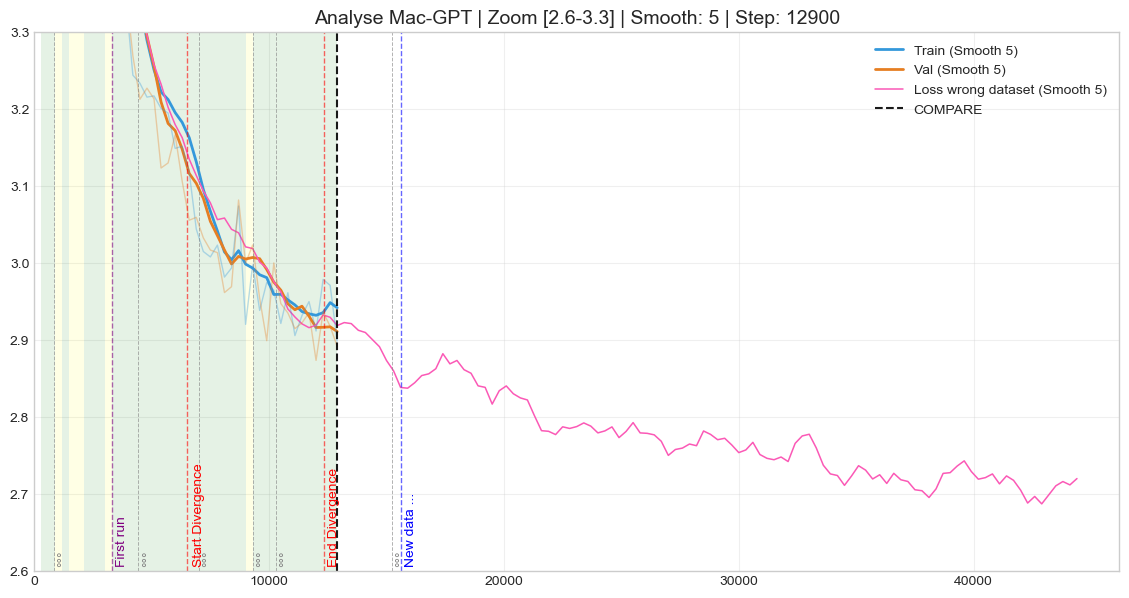

Dernier Step: 12900 | Gap: -0.0067 
COMPARE POINT ANALYSIS:
  - Val Loss: 2.8919 vs 2.8831
  - EMA Loss: 3.049 vs 3.056


In [130]:
plot_poussin_gap(y_min=2.6, y_max=3.3, smooth=5, log_path='model/my_wiky_history.json', second='save/model_2/my_wiky_history.json', compare=12900,
                 annot_event=[
                              {'step':825, 'label':'°°°', 'color':'gray','lw':0.7},
                              {'step':3300, 'label':'First run', 'color':'purple'},
                              {'step':4425, 'label':'°°°', 'color':'gray','lw':0.7},
                              {'step':6525, 'label':'Start Divergence', 'color':'red'},
                              {'step':7002, 'label':'°°°', 'color':'gray','lw':0.7},
                              {'step':9300, 'label':'°°°', 'color':'gray','lw':0.7},
                              {'step':10275, 'label':'°°°', 'color':'gray','lw':0.7},
                              {'step':12325, 'label':'End Divergence', 'color':'red'},
                              {'step':15225, 'label':'°°°', 'color':'gray','lw':0.7},
                              {'step':15600, 'label':'New data ...', 'color':'blue'}])


In [ ]:
import re
import matplotlib.pyplot as plt
import glob
import os
import pandas as pd
import time

def plot_poussin_dashboard(log_folder='model/'):
    data_points = []
    # Récupération de tous les fichiers training*.log
    files = glob.glob(os.path.join(log_folder, 'training*.log'))
    
    if not files:
        print(f"❌ Aucun fichier log trouvé dans {log_folder}")
        return

    # Regex pour extraire les données
    pattern = re.compile(r"step (\d+): train loss ([\d\.]+), val loss ([\d\.]+), lr [\d\.e-]+ \(([\d\.]+)s\)")

    for file_path in files:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                match = pattern.search(line)
                if match:
                    data_points.append({
                        'step': int(match.group(1)),
                        'train': float(match.group(2)),
                        'val': float(match.group(3)),
                        'time_block': float(match.group(4))
                    })

    # 1. Préparation des données avec Pandas
    df = pd.DataFrame(data_points).drop_duplicates(subset='step').sort_values('step')
    
    # Calcul du temps par step réel (différentiel)
    df['step_diff'] = df['step'].diff()
    df['time_per_step'] = df['time_block'] / df['step_diff']
    
    # Lissage des courbes (Moyenne mobile sur 20 points pour la lisibilité)
    df['val_smooth'] = df['val'].rolling(window=10, min_periods=1).mean()
    df['train_smooth'] = df['train'].rolling(window=10, min_periods=1).mean()

    # Nettoyage des valeurs aberrantes pour le graphique du temps
    df.loc[df['time_per_step'] > 15, 'time_per_step'] = None 

    # --- Configuration du Dashboard ---
    plt.style.use('dark_background') # Plus reposant pour les yeux
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
    plt.subplots_adjust(hspace=0.2)

    # --- GRAPHIQUE 1 : LOSS (LISIBILITÉ AMÉLIORÉE) ---
    # Points bruts très discrets
    ax1.plot(df['step'], df['val'], color='red', alpha=0.1, linewidth=0.5)
    
    # Courbes lissées (Tendance)
    ax1.plot(df['step'], df['val_smooth'], color='#ff4757', linewidth=2.5, label='Val Loss (Lissée)')
    ax1.plot(df['step'], df['train_smooth'], color="#bec2cc", linewidth=1.5, label='Train Loss (Lissée)', alpha=0.8)
    
    # Ligne de record (Ton objectif 2.613)
    record_val = 2.613
    ax1.axhline(y=record_val, color='#eccc68', linestyle='--', linewidth=2, label=f'Record Nuit ({record_val})')
    
    # Zoom intelligent sur la zone de combat (évite d'écraser le graph avec le début à 10.0)
    current_min = df['val_smooth'].min()
    ax1.set_ylim(current_min * 0.96, current_min * 1.10) 
    
    ax1.set_title(f"Poussin-v2 Dashboard | Dernier Step: {df['step'].iloc[-1]}", fontsize=16, color='white', pad=20)
    ax1.set_ylabel("Cross Entropy Loss", fontsize=12)
    ax1.legend(loc='upper right', frameon=True, facecolor='#2f3542')
    ax1.grid(True, alpha=0.1)

    # --- GRAPHIQUE 2 : PERFORMANCE MATÉRIELLE ---
    # Points de performance par step
    ax2.scatter(df['step'], df['time_per_step'], s=8, color='#7bed9f', alpha=0.3, label='Temps/Step brut')
    ax2.plot(df['step'], df['time_per_step'].rolling(window=15).mean(), color='#2ed573', linewidth=2, label='Stabilité Mac Pro')
    
    ax2.set_ylabel("Secondes / 1 Step", fontsize=12)
    ax2.set_xlabel("Total Training Steps", fontsize=12)
    
    # Formatage de l'axe X en milliers (k)
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
    
    # Zoom sur l'axe Y pour le temps (on ignore les pics de démarrage)
    if not df['time_per_step'].dropna().empty:
        ax2.set_ylim(0, df['time_per_step'].quantile(0.98))
        
    ax2.legend(loc='upper right', frameon=True, facecolor='#2f3542')
    ax2.grid(True, alpha=0.1)

    # Affichage des stats finales en texte sur le graph
    last_val = df['val'].iloc[-1]
    plt.annotate(f"Current Val Loss: {last_val:.4f}", xy=(0.02, 0.95), xycoords='axes fraction', 
                 fontsize=12, color='white', weight='bold')

    plt.show()

# Lancement
plot_poussin_dashboard('model/')

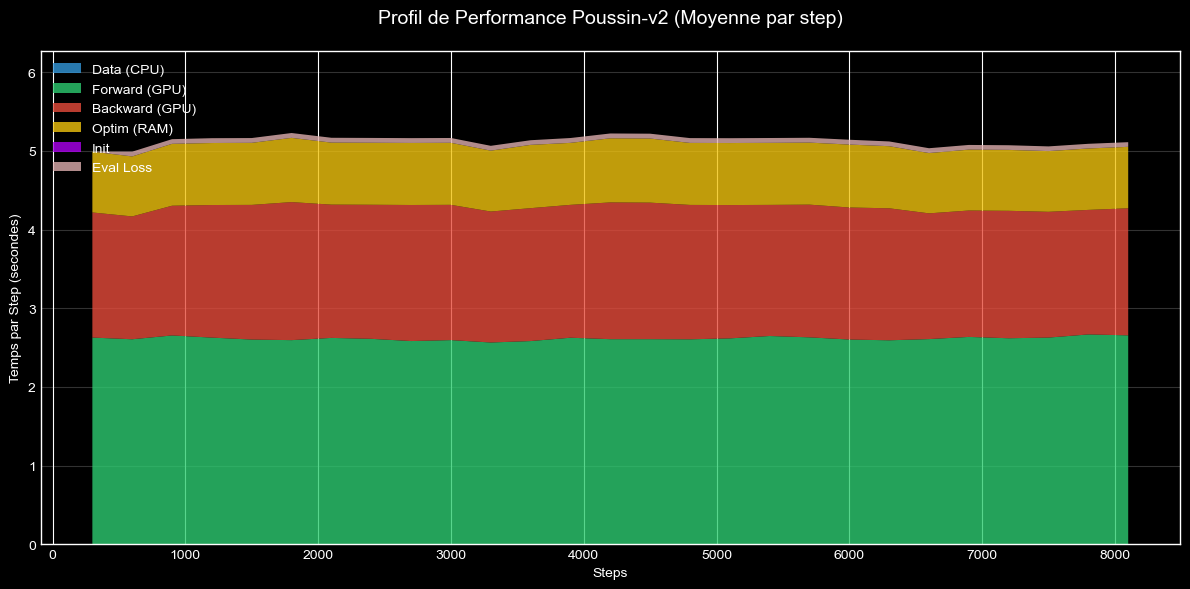

In [74]:
import json
import matplotlib.pyplot as plt
import numpy as np

ACCUM_BATCH = 4

def plot_training_performance(json_path):
    # 1. Chargement des données
    with open(json_path, 'r') as f:
        data = json.load(f)

    # On récupère les différents temps
    steps = data['steps']
    
    # Calcul de la différence (dérivée) pour retrouver le temps par segment
    # t_batch = np.diff(data['time_batch'], prepend=0) 
    # t_model = np.diff(data['time_model'], prepend=0) 
    # t_backw = np.diff(data['time_bacwd'], prepend=0)
    # t_optim = np.diff(data['time_optim'], prepend=0)
    t_init = np.array(data['time_init'])
    t_batch = np.array(data['time_batch'])
    t_model = np.array(data['time_model'])
    t_backw = np.array(data['time_bacwd'])
    t_optim = np.array(data['time_optim'])
    t_eval = np.array(data['time_eval'])

    # plt.figure(figsize=(12, 7))
    
    # 2. Création du graphique
    plt.style.use('dark_background') # Plus sympa pour le Mac Pro
    fig, ax = plt.subplots(figsize=(12, 6))

    # On empile les aires
    labels = ['Data (CPU)', 'Forward (GPU)', 'Backward (GPU)', 'Optim (RAM)', 'Init', 'Eval Loss']
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#f1c40f','#ad00f0','#dfafaf']
    
    ax.stackplot(steps, t_batch, t_model, t_backw, t_optim, t_init, t_eval,
                 labels=labels, colors=colors, alpha=0.8)

    # ax.set_xlim(steps[-50], steps[-1])

    # 3. Cosmétique
    ax.set_title(f"Profil de Performance Poussin-v2 (Moyenne par step)", fontsize=14, pad=20)
    ax.set_xlabel("Steps")
    ax.set_ylabel("Temps par Step (secondes)")
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.2)

    # Limiter l'axe Y pour mieux voir si un petit temps ressort
    ax.set_ylim(0, max(t_batch + t_model + t_backw + t_optim + t_init + t_eval) * 1.2)

    plt.tight_layout()
    plt.savefig('performance_clean.png')
    plt.show()

# Utilisation :
plot_training_performance('model/my_wiky_history.json')

In [ ]:
import torch
sd = torch.load('model/my_wiki_inference.pth', map_location='cpu')
model = sd['model']
print(f'Taille réelle : {sum(t.numel() for t in model.values() if isinstance(t, torch.Tensor))/1e6:.2f}M paramètres')
ckpt = torch.load('model/my_wiki.pth', map_location='cpu')
print(ckpt.keys())

In [ ]:
import tools.ai_gpt_ep as gpt
visualizer = gpt.TrainingVisualizer('save/model/my_wiky_history.json')
visualizer.plot_metrics(window_size=10, lim_y=(2.5,10.2)) # Lissage sur 10 fichiers